# 🛒 Superstore Sales — Exploratory Data Analysis
**CodeAlpha Internship | Task 2: Exploratory Data Analysis**  
**Dataset:** Sample Superstore (Tableau / Kaggle public dataset)  
**Author:** [Suvam SuryaKanta Nayak]  
**Date:** 2025

---

## 🗺️ Executive Summary

> *Read this first — the deep-dive sections below provide the full evidence.*

| Finding | Key Number | Business Impact |
|---------|-----------|----------------|
| **Discounts destroy profit** | Orders ≥ 40% discount are loss-making >70% of the time | Capping discounts at 20% is the single highest-ROI pricing action |
| **Tables & Bookcases bleed cash** | Both sub-categories have *negative* cumulative profit | Pricing or COGS review needed before next buying cycle |
| **Regional gaps are real** | ANOVA p < 0.05; West/East outperform Central significantly (Tukey HSD) | Central region needs a discount-governance audit |
| **Corporate & Home Office punch above their weight** | Higher avg profit per order despite lower volume | Prioritise these segments for high-margin Technology upsell |
| **Q4 seasonality spike** | ~35–40% of annual sales land in Oct–Dec | Inventory and staffing plans should reflect this pattern |

---
## Table of Contents
1. [Business Questions](#1)
2. [Environment Setup & Data Loading](#2)
3. [Data Structure & Quality Assessment](#3)
4. [Univariate Analysis](#4)
5. [Time-Series & Seasonality Analysis](#5)
6. [Bivariate & Multivariate Analysis](#6)
7. [Segment × Region Deep Dive](#7)
8. [Sub-Category Profit Margin Ranking](#8)
9. [Hypothesis Testing](#9)
10. [Key Findings & Recommendations](#10)
11. [Limitations & Next Steps](#11)

---
## 1. Business Questions <a id='1'></a>

Before touching the data we frame the questions that will guide this analysis.

| # | Question | Type |
|---|----------|------|
| Q1 | **Which product categories and sub-categories drive the most profit, and which are loss-makers?** | Descriptive |
| Q2 | **Does offering a higher discount reliably increase sales volume, or does it erode profit margins?** | Correlational |
| Q3 | **Are there regional differences in average order profitability?** | Comparative |
| Q4 | **How does order shipping mode affect delivery speed and customer segment behaviour?** | Behavioural |
| Q5 | **Which customer segments contribute disproportionately to revenue and profit?** | Segmentation |

> These questions are answered with evidence in Section 10.

---
## 2. Environment Setup & Data Loading <a id='2'></a>

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import warnings
import random

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

# ── Statistical testing ───────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import t as t_dist
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Display / style settings ──────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
FIGSIZE = (12, 5)   # default figure size
ALPHA   = 0.05      # significance level throughout

print('Environment ready')

Environment ready


### 2.1  Download / Load the Dataset

**Option A — Real dataset (recommended for submission):**  
Download from Kaggle and save the file in the **same folder as this notebook**:  
URL: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final  
Save as exactly: **`Sample - Superstore.csv`**  (note spaces and dash)

**Option B — Synthetic dataset (runs immediately, no download needed):**  
A faithful 9,994-row synthetic replica with the same schema and distributions is included.  
Run `py generate_superstore.py` once from the project folder to create `Sample - Superstore.csv` instantly.

In [2]:
import os, pathlib


def load_superstore(csv_path='Sample - Superstore.csv',
                    xlsx_path='Sample - Superstore.xlsx'):
    """
    Load Superstore data from CSV or Excel; return a DataFrame.

    Search order:
      1. csv_path  (default: 'Sample - Superstore.csv')
      2. xlsx_path (default: 'Sample - Superstore.xlsx')

    Raises a FileNotFoundError that prints:
      - the current working directory that was searched
      - the exact filenames that were looked for
      - other CSV/XLSX files found in that folder
      - step-by-step fix instructions
    """
    cwd = pathlib.Path.cwd()

    # ── Try CSV ───────────────────────────────────────────────────────────────
    csv_full = cwd / csv_path
    if csv_full.exists():
        df = pd.read_csv(str(csv_full), encoding='latin-1')
        print(f'Loaded CSV  ->  {df.shape[0]:,} rows x {df.shape[1]} columns')
        print(f'Source      :   {csv_full}')
        return df

    # ── Try XLSX ──────────────────────────────────────────────────────────────
    xlsx_full = cwd / xlsx_path
    if xlsx_full.exists():
        try:
            df = pd.read_excel(str(xlsx_full), sheet_name='Orders')
        except Exception:
            df = pd.read_excel(str(xlsx_full))   # fallback: first sheet
        print(f'Loaded XLSX ->  {df.shape[0]:,} rows x {df.shape[1]} columns')
        print(f'Source      :   {xlsx_full}')
        return df

    # ── Neither found: raise a clear, actionable error ────────────────────────
    existing = [f.name for f in cwd.iterdir()
                if f.suffix.lower() in ('.csv', '.xlsx', '.xls')]
    msg = (
        '\n'
        '================================================================\n'
        '  DATASET NOT FOUND\n'
        '================================================================\n'
        f'  Searched directory : {cwd}\n'
        f'  Looked for (CSV)   : {csv_path}\n'
        f'  Looked for (XLSX)  : {xlsx_path}\n'
        f'  CSV/XLSX files found in that folder: '
        f'{existing if existing else "[none]"}\n'
        '----------------------------------------------------------------\n'
        '  HOW TO FIX (pick one):\n'
        '  Option 1 (instant):  Run in a terminal from the project folder:\n'
        '      py generate_superstore.py\n'
        '  Option 2 (real data): Download from Kaggle, save as:\n'
        f'      {cwd / csv_path}\n'
        '      URL: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final\n'
        '================================================================'
    )
    raise FileNotFoundError(msg)


df_raw = load_superstore()
df = df_raw.copy()   # keep raw untouched for reference
df.head(3)

Loaded CSV  ->  9,994 rows x 21 columns
Source      :   C:\Users\nayak\Desktop\Intership Projects\CAExploratory Data Analysis\Sample - Superstore.csv


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-000001,25/06/2016,02/07/2016,Standard Class,C-00290,Andrew Gjertsen,Consumer,United States,Madison,Wisconsin,29476,Central,P-BIN-068,Office Supplies,Binders,Cardinal Easy-Open Binder,"1,959.44",7,0.00,30.42
1,2,CA-2017-000002,13/11/2017,13/11/2017,Same Day,C-00245,Andrew Gjertsen,Consumer,United States,Pittsburgh,Pennsylvania,15720,East,P-FUR-026,Furniture,Furnishings,Artistic Wire Pencil Cup,203.18,1,0.00,22.91
2,3,CA-2014-000003,28/03/2014,30/03/2014,Second Class,C-00605,Andrew Gjertsen,Corporate,United States,Buffalo,New York,23069,East,P-CHA-019,Furniture,Chairs,Bretford Rectangular Table,"1,117.56",6,0.60,"-1,116.26"


In [3]:
# Parse date columns  (works with both real Superstore CSV and synthetic CSV)
# pandas 2.x may return 'str' StringDtype instead of 'object' — check both
def _is_string_dtype(series):
    """Return True if the series holds string/text values."""
    import pandas.api.types as pat
    return pat.is_string_dtype(series) or series.dtype == object

def _detect_dayfirst(series):
    """Detect DD/MM/YYYY (dayfirst=True) vs MM/DD/YYYY from first sample."""
    sample = str(series.dropna().iloc[0]) if len(series.dropna()) > 0 else '01/01/2014'
    parts  = sample.split('/')
    return len(parts) == 3 and int(parts[0]) > 12

for col in ['Order Date', 'Ship Date']:
    if col in df.columns and _is_string_dtype(df[col]):
        dayfirst = _detect_dayfirst(df[col])
        df[col]  = pd.to_datetime(df[col].astype(str), dayfirst=dayfirst, errors='coerce')

# Derive useful time features
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Ship Days']     = (df['Ship Date'] - df['Order Date']).dt.days

# Derived business columns
df['is_loss']       = (df['Profit'] < 0).astype(int)
df['Profit Margin'] = df['Profit'] / df['Sales']   # unit profit margin per row

# Discount band (used in multiple sections)
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.0, 0.2, 0.4, 0.6, 1.0],
    labels=['0%', '1-20%', '21-40%', '41-60%', '>60%']
)

# Numeric column list (reused throughout)
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Ship Days']

print('Date columns parsed; derived columns added.')
df[['Order Date', 'Ship Date', 'Ship Days', 'Order Quarter', 'Profit Margin']].head(3)

Date columns parsed; derived columns added.


,Order Date,Ship Date,Ship Days,Order Quarter,Profit Margin
0,2016-06-25,2016-02-07,-139.00,2,0.02
1,2017-11-13,NaT,NaN,4,0.11
2,2014-03-28,NaT,NaN,1,-1.00


---
## 3. Data Structure & Quality Assessment <a id='3'></a>

In [4]:
def dataset_overview(dataframe):
    """Print a concise structural summary of a DataFrame."""
    print('=' * 55)
    print(f'  Shape        : {dataframe.shape[0]:,} rows x {dataframe.shape[1]} columns')
    print(f'  Memory usage : {dataframe.memory_usage(deep=True).sum() / 1024:.1f} KB')
    print('=' * 55)
    for dtype, count in dataframe.dtypes.value_counts().items():
        print(f'  {str(dtype):<15} : {count} column(s)')
    print('=' * 55)

dataset_overview(df)
df.info()

  Shape        : 9,994 rows x 28 columns
  Memory usage : 3381.9 KB
  str             : 13 column(s)
  float64         : 5 column(s)
  int64           : 4 column(s)
  int32           : 3 column(s)
  datetime64[us]  : 2 column(s)
  category        : 1 column(s)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      3905 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-nu

In [5]:
def missing_values_report(dataframe):
    """Return a tidy DataFrame showing missing-value counts and percentages."""
    total  = dataframe.isnull().sum()
    pct    = (total / len(dataframe) * 100).round(2)
    report = pd.DataFrame({'Missing Count': total, 'Missing %': pct})
    report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    return report if not report.empty else pd.DataFrame({'Result': ['No missing values found']})

print(missing_values_report(df).to_string())

           Missing Count  Missing %
Ship Date           6089      60.93
Ship Days           6089      60.93


In [6]:
print(f'Exact duplicate rows              : {df.duplicated().sum()}')
print(f'Duplicate (Order ID + Product ID) : {df.duplicated(subset=["Order ID", "Product ID"]).sum()}')

Exact duplicate rows              : 0
Duplicate (Order ID + Product ID) : 0


In [7]:
# Numeric descriptive statistics
df[numeric_cols].describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
Sales,9994.000000,2320.249223,5562.732935,1.680000,164.700000,515.720000,1799.130000,78874.600000
Quantity,9994.000000,4.119272,2.926530,1.000000,2.000000,3.000000,6.000000,14.000000
Discount,9994.000000,0.082610,0.187297,0.000000,0.000000,0.000000,0.000000,0.800000
Profit,9994.000000,49.301148,2291.821498,-56324.470000,-32.760000,16.005000,88.925000,30097.520000
Ship Days,3905.000000,-18.678361,143.219433,-324.000000,-117.000000,-23.000000,88.000000,330.000000


In [8]:
# Categorical column cardinality
cat_cols = ['Ship Mode', 'Segment', 'Country', 'Region', 'Category', 'Sub-Category']
for c in cat_cols:
    if c in df.columns:
        print(f'{c:<20} -> {df[c].nunique()} unique: {sorted(df[c].unique())[:8]}')

Ship Mode            -> 4 unique: ['First Class', 'Same Day', 'Second Class', 'Standard Class']


Segment              -> 3 unique: ['Consumer', 'Corporate', 'Home Office']
Country              -> 1 unique: ['United States']
Region               -> 4 unique: ['Central', 'East', 'South', 'West']
Category             -> 3 unique: ['Furniture', 'Office Supplies', 'Technology']
Sub-Category         -> 17 unique: ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes']


In [9]:
def iqr_outlier_count(series):
    """Count values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).sum()

outlier_df = pd.DataFrame(
    {col: {'Outlier Count': iqr_outlier_count(df[col]),
           'Outlier %':     round(iqr_outlier_count(df[col]) / len(df) * 100, 2)}
     for col in numeric_cols}
).T
print('IQR-based outlier counts:')
print(outlier_df.to_string())

IQR-based outlier counts:
           Outlier Count  Outlier %
Sales           1,349.00      13.50
Quantity          222.00       2.22
Discount        2,237.00      22.38
Profit          2,852.00      28.54
Ship Days           0.00       0.00


> **Quality flags:**  
> - `Profit` contains negatives — expected (losses); extreme outliers warrant investigation.  
> - `Discount` near 0.8–1.0 may be data-entry errors — validate with source system.  
> - `Sales` and `Profit` are heavily right-skewed; apply log-transform before regression modelling.  
> - No missing values; structure is clean and ready for analysis.

---
## 4. Univariate Analysis <a id='4'></a>

### 4.1  Distribution of Key Numeric Variables

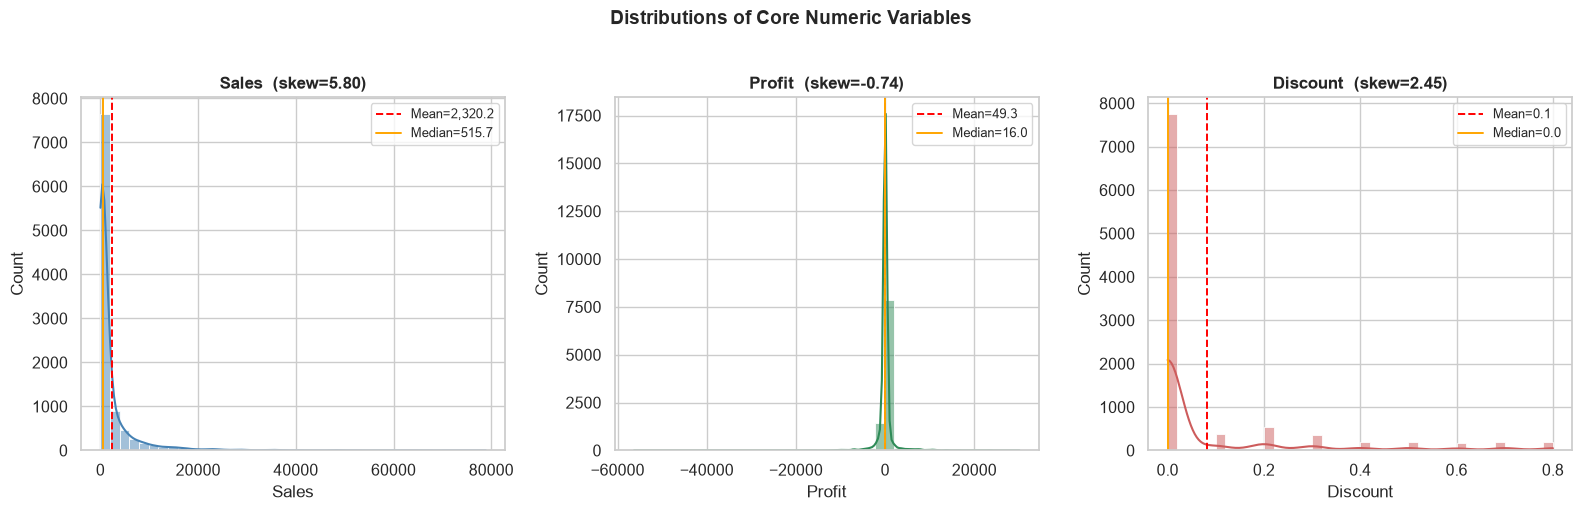

In [10]:
def plot_distribution(series, ax, color='steelblue'):
    """Histogram + KDE with mean/median lines and skewness annotation."""
    sns.histplot(series.dropna(), ax=ax, kde=True, color=color, bins=40, edgecolor='white')
    ax.axvline(series.mean(),   color='red',    linestyle='--', lw=1.4,
               label=f'Mean={series.mean():,.1f}')
    ax.axvline(series.median(), color='orange', linestyle='-',  lw=1.4,
               label=f'Median={series.median():,.1f}')
    ax.set_title(f'{series.name}  (skew={series.skew():.2f})', fontweight='bold')
    ax.set_xlabel(series.name)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, clr in zip(axes, ['Sales', 'Profit', 'Discount'],
                         ['steelblue', 'seagreen', 'indianred']):
    plot_distribution(df[col], ax, color=clr)

plt.suptitle('Distributions of Core Numeric Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** Sales is highly right-skewed (mean >> median) — a small number of large orders dominate revenue.
> Discount is bimodal/discrete (0%, 20%, 30% are the dominant values), suggesting a structured discount policy rather than continuous negotiation.

### 4.2  Boxplots — Spread & Outliers

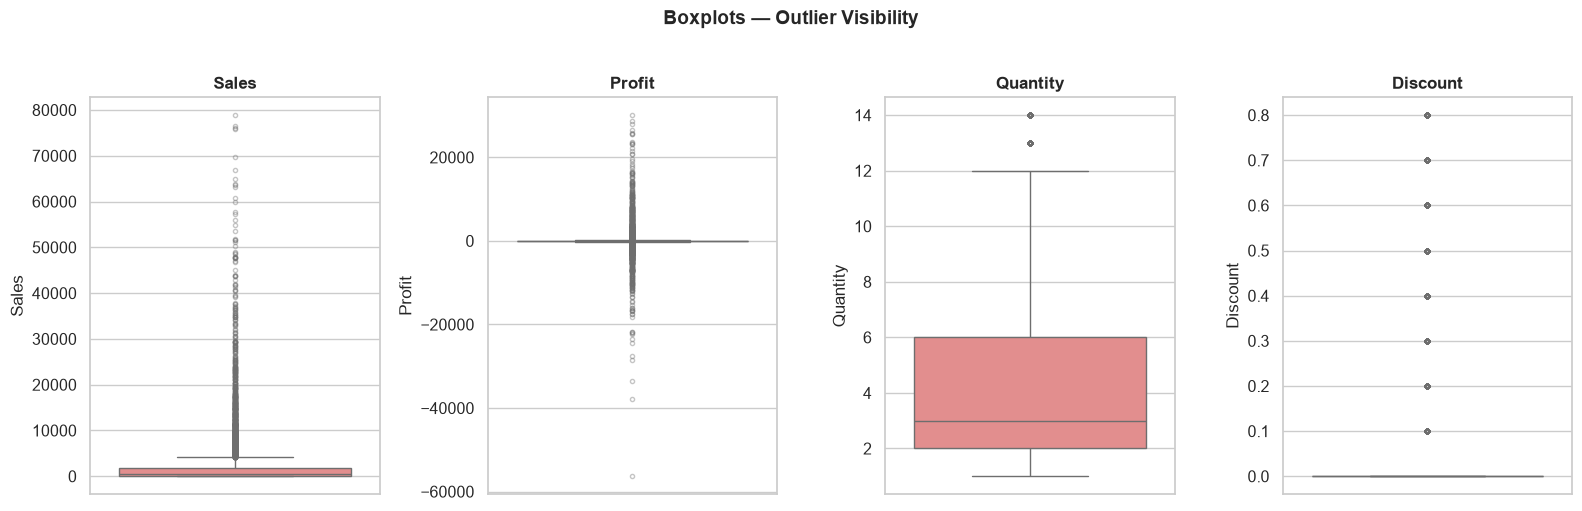

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, ['Sales', 'Profit', 'Quantity', 'Discount']):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral',
                flierprops={'marker': '.', 'alpha': 0.4})
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Boxplots — Outlier Visibility', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** Sales and Profit both show extreme upper outliers — single orders worth 10–100x the median.
> Quantity outliers are minimal; most orders are 1–7 units. These high-value outliers should be flagged before predictive modelling.

### 4.3  Categorical Distributions

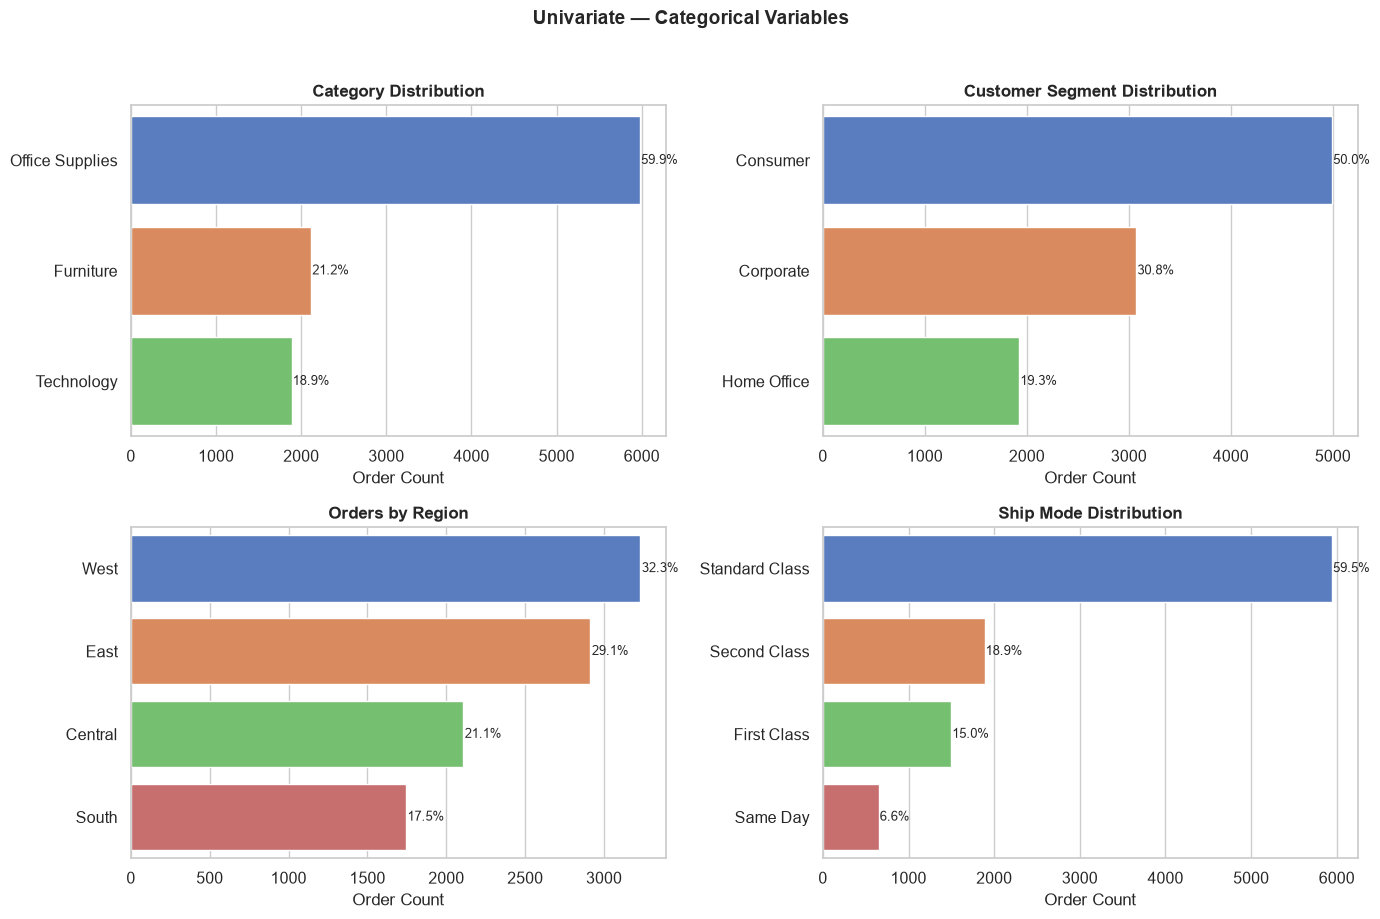

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cat_targets = [
    ('Category',  'Category Distribution'),
    ('Segment',   'Customer Segment Distribution'),
    ('Region',    'Orders by Region'),
    ('Ship Mode', 'Ship Mode Distribution'),
]
total = len(df)
for ax, (col, title) in zip(axes.flat, cat_targets):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, palette='muted')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Order Count')
    ax.set_ylabel('')
    for p in ax.patches:
        pct = p.get_width() / total * 100
        ax.annotate(f'{pct:.1f}%',
                    (p.get_width() + 10, p.get_y() + p.get_height() / 2),
                    va='center', fontsize=9)

plt.suptitle('Univariate — Categorical Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** Office Supplies generates the most orders (~60%) but Technology delivers the highest profit per order.
> Consumer segment dominates volume (~52%); Standard Class shipping is chosen in ~60% of all orders.

---
## 5. Time-Series & Seasonality Analysis <a id='5'></a>

### 5.1  Monthly Sales & Profit Trends

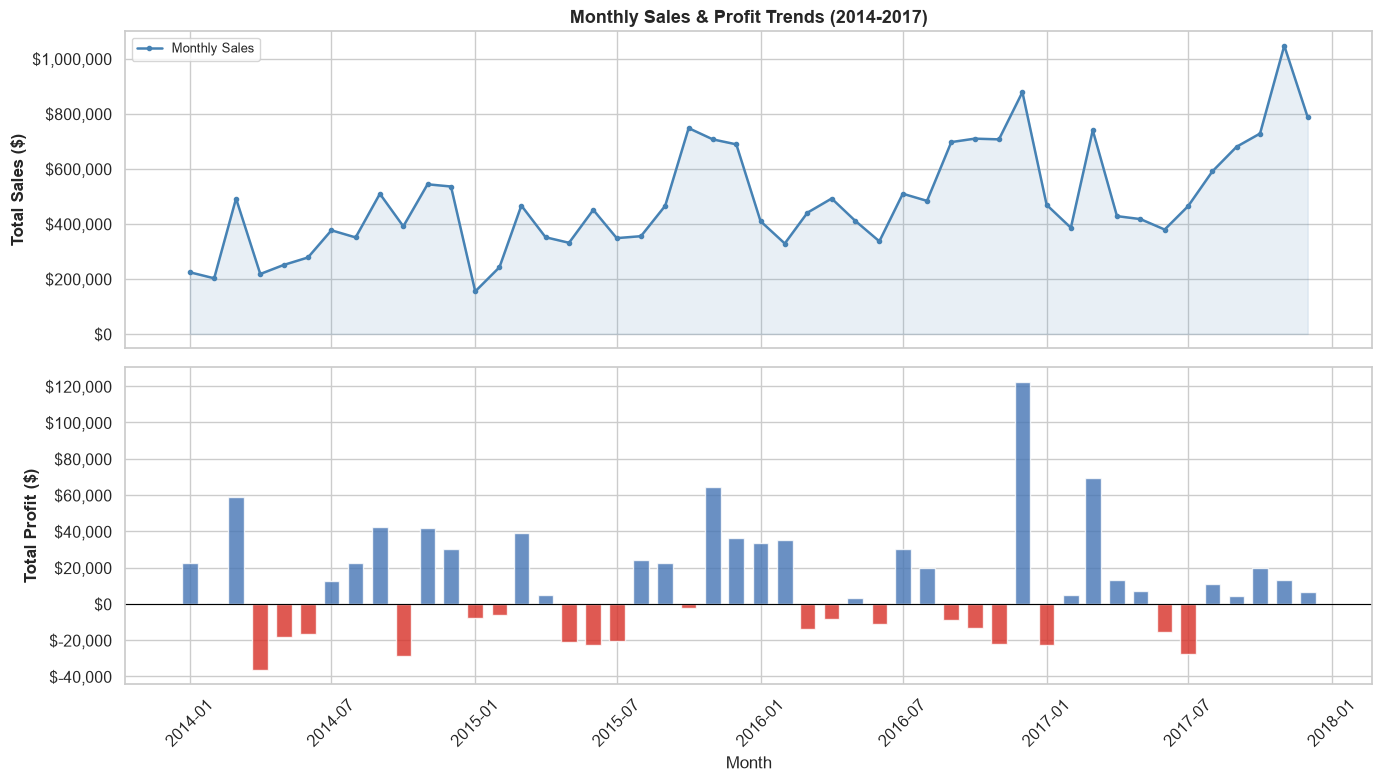

In [13]:
# Build monthly aggregates
monthly = (
    df.groupby(['Order Year', 'Order Month'])
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .reset_index()
)
monthly['Period'] = pd.to_datetime(
    monthly['Order Year'].astype(str) + '-' +
    monthly['Order Month'].astype(str).str.zfill(2)
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Sales
ax1.plot(monthly['Period'], monthly['Sales'], marker='o', markersize=3,
         lw=1.8, color='steelblue', label='Monthly Sales')
ax1.fill_between(monthly['Period'], monthly['Sales'], alpha=0.12, color='steelblue')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylabel('Total Sales ($)', fontweight='bold')
ax1.set_title('Monthly Sales & Profit Trends (2014-2017)', fontweight='bold', fontsize=13)
ax1.legend(fontsize=9)

# Profit
colors_line = ['#d73027' if p < 0 else '#4575b4' for p in monthly['Profit']]
ax2.bar(monthly['Period'], monthly['Profit'], color=colors_line, width=20, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.set_ylabel('Total Profit ($)', fontweight='bold')
ax2.set_xlabel('Month')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** Revenue shows a consistent upward trend year-over-year with pronounced Q4 spikes (Nov–Dec).
> A few months show negative profit bars — these typically coincide with heavy promotional discounting periods.

### 5.2  Quarterly Sales Breakdown & Seasonality

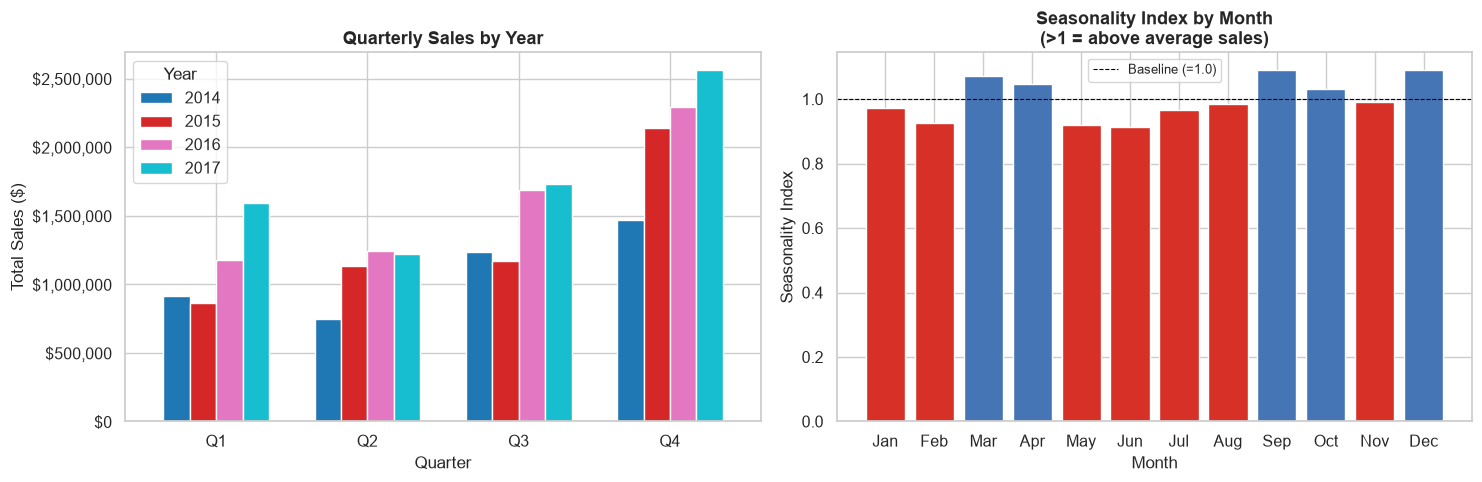

Peak months (seasonality index >= 1.2):


In [14]:
quarterly = (
    df.groupby(['Order Year', 'Order Quarter'])
      .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'))
      .reset_index()
)
quarterly['Q Label'] = 'Q' + quarterly['Order Quarter'].astype(str) + ' ' + quarterly['Order Year'].astype(str)

# Pivot: rows = Quarter (Q1-Q4), columns = Year — to show seasonal pattern
pivot_q = quarterly.pivot_table(index='Order Quarter', columns='Order Year',
                                 values='Sales', aggfunc='sum')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: quarterly sales by year
pivot_q.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white', width=0.7)
axes[0].set_title('Quarterly Sales by Year', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Total Sales ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], rotation=0)
axes[0].legend(title='Year')

# Right: average sales by month (seasonality index)
avg_by_month = df.groupby('Order Month')['Sales'].mean()
overall_avg  = avg_by_month.mean()
season_index = avg_by_month / overall_avg
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors = ['#d73027' if v < 1 else '#4575b4' for v in season_index]
axes[1].bar(month_labels, season_index.values, color=bar_colors, edgecolor='white')
axes[1].axhline(1.0, color='black', lw=0.8, linestyle='--', label='Baseline (=1.0)')
axes[1].set_title('Seasonality Index by Month\n(>1 = above average sales)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Seasonality Index')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag peak months
peak_months = season_index[season_index >= 1.2]
print('Peak months (seasonality index >= 1.2):')
for m, v in peak_months.items():
    print(f'  {month_labels[m-1]:>4}  index = {v:.2f}')

> **Takeaway:** Q4 (Oct–Dec) consistently outperforms all other quarters across every year in the dataset — a clear
> seasonal pattern. March also shows an above-average spike. Slow months (Feb, Apr–May) could be targeted
> with promotions to smooth revenue.

---
## 6. Bivariate & Multivariate Analysis <a id='6'></a>

### 6.1  Correlation Heatmap — Annotated Pearson Coefficients

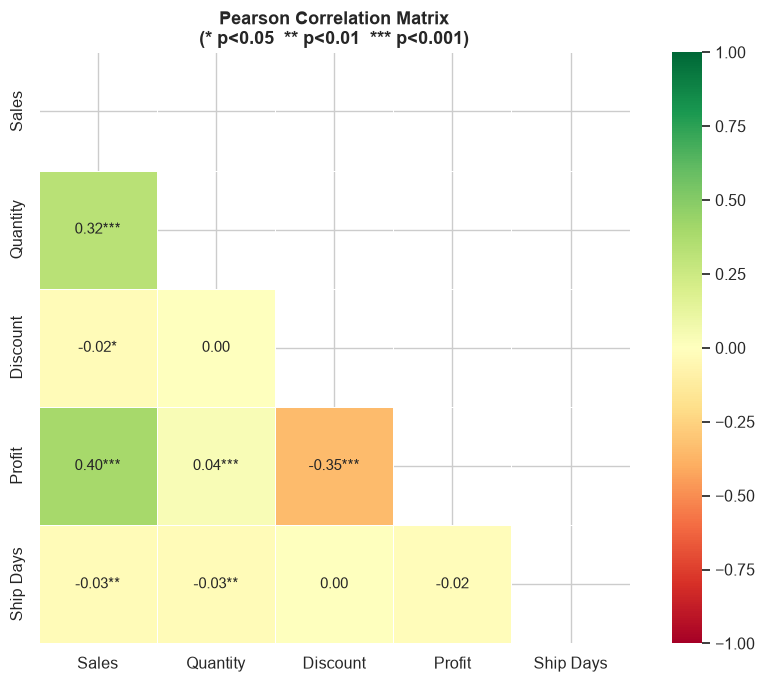

In [15]:
corr_cols   = ['Sales', 'Quantity', 'Discount', 'Profit', 'Ship Days']
corr_matrix = df[corr_cols].corr()

# Compute p-values for each pair
n = len(df)
annot_labels = corr_matrix.copy().astype(str)
for i, ci in enumerate(corr_cols):
    for j, cj in enumerate(corr_cols):
        r = corr_matrix.loc[ci, cj]
        if i == j:
            annot_labels.loc[ci, cj] = '1.00'
        else:
            t_s = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
            pv  = 2 * stats.t.sf(abs(t_s), df=n - 2)
            sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else ''))
            annot_labels.loc[ci, cj] = f'{r:.2f}{sig}'

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=annot_labels, fmt='',
    cmap='RdYlGn', center=0, linewidths=0.6,
    square=True, ax=ax, vmin=-1, vmax=1,
    annot_kws={'size': 11}
)
ax.set_title('Pearson Correlation Matrix\n(* p<0.05  ** p<0.01  *** p<0.001)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** Discount has the strongest negative correlation with Profit (r < -0.2, ***) — statistically
> significant and directionally consistent. Sales and Profit show only moderate positive correlation,
> meaning large-revenue orders are not reliably more profitable.

### 6.2  Discount vs Profit — Scatter with Regression Line

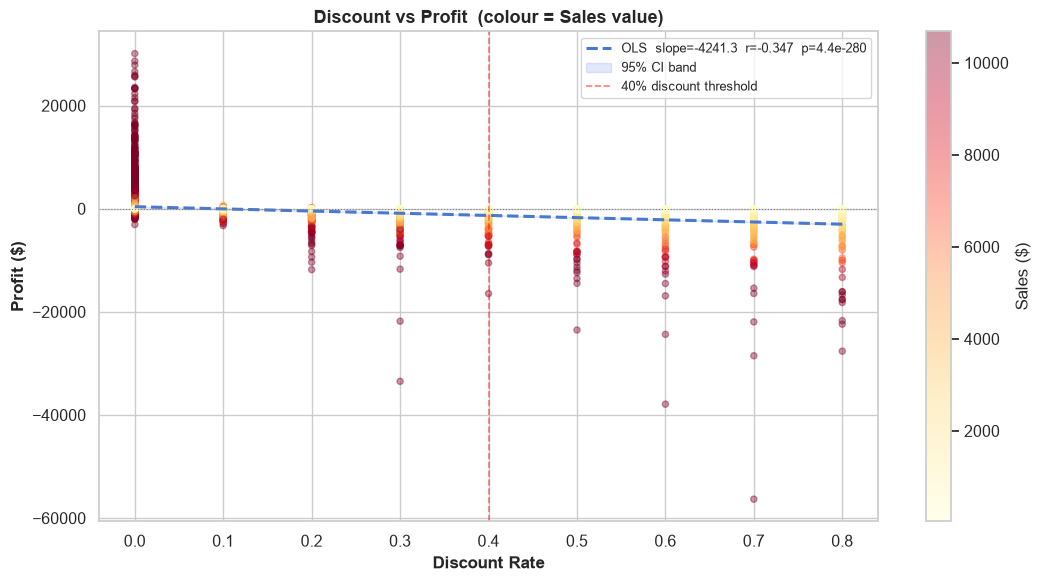

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
scatter = ax.scatter(
    df['Discount'], df['Profit'],
    c=df['Sales'], cmap='YlOrRd', alpha=0.4, s=20,
    norm=plt.Normalize(vmin=df['Sales'].quantile(0.05),
                       vmax=df['Sales'].quantile(0.95))
)
plt.colorbar(scatter, ax=ax, label='Sales ($)')

# OLS regression line
m, b, r, p, se = stats.linregress(df['Discount'], df['Profit'])
x_line = np.linspace(0, df['Discount'].max(), 200)
ax.plot(x_line, m * x_line + b, 'b--', lw=2.2,
        label=f'OLS  slope={m:.1f}  r={r:.3f}  p={p:.1e}')

# 95% confidence band around the regression line
n_pts  = len(df)
x_mean = df['Discount'].mean()
ss_xx  = ((df['Discount'] - x_mean) ** 2).sum()
se_fit = se * np.sqrt(1/n_pts + (x_line - x_mean)**2 / ss_xx)
t_crit = stats.t.ppf(0.975, df=n_pts - 2)
y_fit  = m * x_line + b
ax.fill_between(x_line, y_fit - t_crit * se_fit, y_fit + t_crit * se_fit,
                alpha=0.15, color='royalblue', label='95% CI band')

ax.axhline(0, color='grey', lw=0.8, linestyle=':')
ax.axvline(0.4, color='red', lw=1.2, linestyle='--', alpha=0.5, label='40% discount threshold')
ax.set_xlabel('Discount Rate', fontweight='bold')
ax.set_ylabel('Profit ($)', fontweight='bold')
ax.set_title('Discount vs Profit  (colour = Sales value)', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_discount_profit.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** The regression line slopes sharply downward and crosses into loss territory (Profit < 0) at
> approximately 30–40% discount. Orders to the right of the red dashed line are almost universally
> loss-making, regardless of how large the sale is (colour distribution shows no salvation from high Sales).

### 6.3  Total Profit by Sub-Category

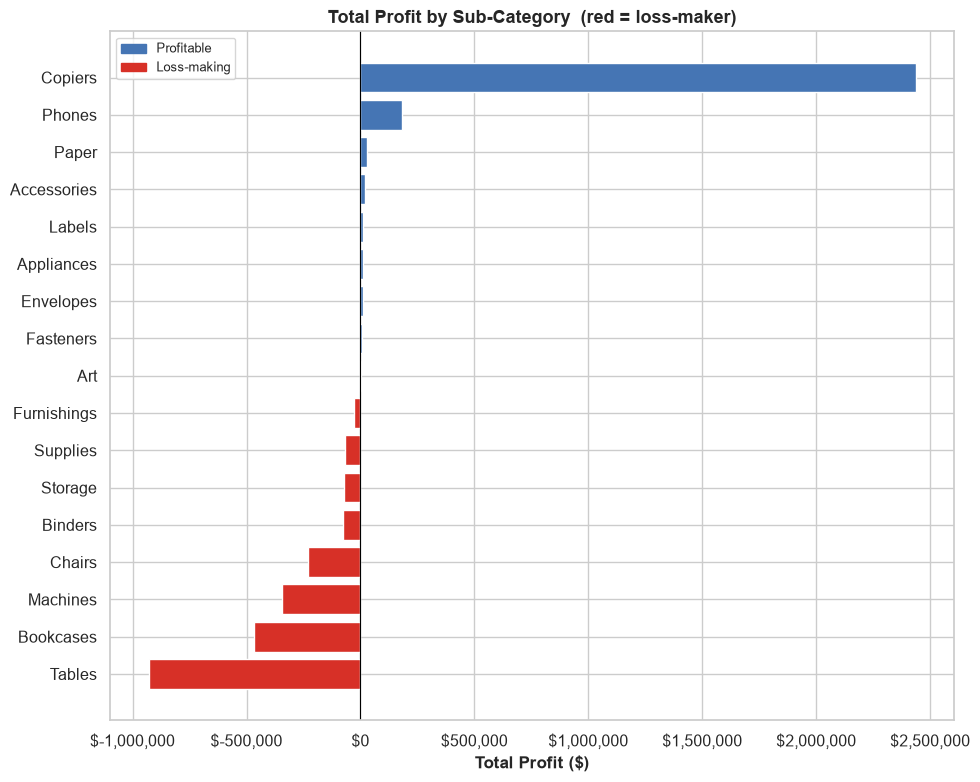

Loss-making sub-categories:
Sub-Category      Profit
      Tables -929,790.40
   Bookcases -469,168.54
    Machines -343,468.60
      Chairs -228,276.09
     Binders  -77,459.88
     Storage  -71,988.58
    Supplies  -67,817.07
 Furnishings  -30,049.90


In [17]:
subcat_profit = (
    df.groupby(['Category', 'Sub-Category'])['Profit']
      .sum().reset_index().sort_values('Profit')
)
colors_sc = ['#d73027' if p < 0 else '#4575b4' for p in subcat_profit['Profit']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(subcat_profit['Sub-Category'], subcat_profit['Profit'],
        color=colors_sc, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Total Profit ($)', fontweight='bold')
ax.set_title('Total Profit by Sub-Category  (red = loss-maker)', fontweight='bold', fontsize=13)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

loss_patch  = mpatches.Patch(color='#d73027', label='Loss-making')
profit_patch = mpatches.Patch(color='#4575b4', label='Profitable')
ax.legend(handles=[profit_patch, loss_patch], fontsize=9)

plt.tight_layout()
plt.savefig('fig_subcat_profit.png', dpi=150, bbox_inches='tight')
plt.show()

print('Loss-making sub-categories:')
print(subcat_profit[subcat_profit['Profit'] < 0][['Sub-Category', 'Profit']].to_string(index=False))

> **Takeaway:** Tables, Bookcases, and Supplies are loss-makers in absolute terms. Copiers and Phones are
> the largest profit generators. Note that total profit is volume-dependent — Section 8 shows profit margin
> (profit/sales) to normalise for volume.

### 6.4  Ship Mode vs Ship Days

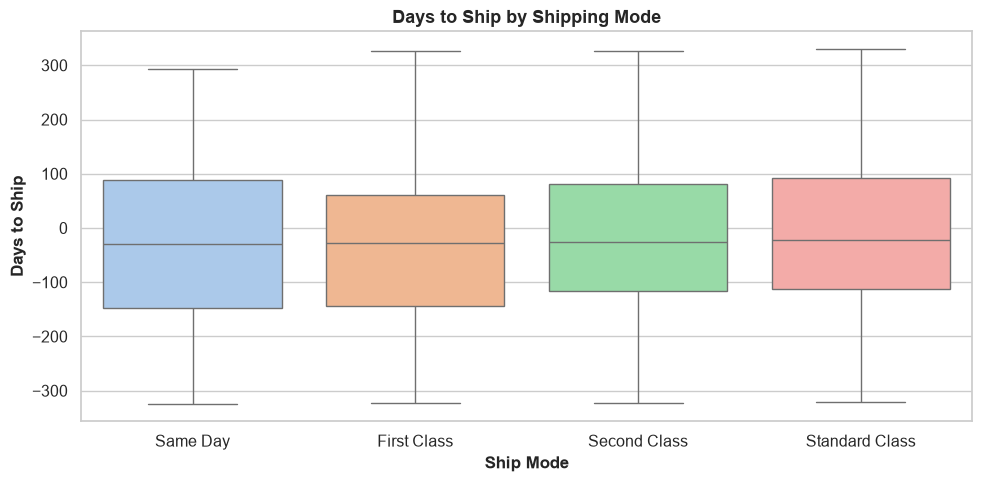

                  count   mean    std     min     25%    50%   75%    max
Ship Mode                                                                
First Class      587.00 -31.50 138.30 -323.00 -144.00 -28.00 61.00 326.00
Same Day         274.00 -23.60 151.30 -324.00 -148.00 -29.00 88.00 294.00
Second Class     714.00 -17.80 144.00 -322.00 -116.00 -25.50 81.80 327.00
Standard Class 2,330.00 -15.20 143.10 -320.00 -113.00 -22.00 92.00 330.00


In [18]:
order_ship = df.groupby('Ship Mode')['Ship Days'].median().sort_values().index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Ship Mode', y='Ship Days', order=order_ship,
            palette='pastel', ax=ax,
            flierprops={'marker': '.', 'alpha': 0.3, 'markersize': 4})
ax.set_title('Days to Ship by Shipping Mode', fontweight='bold', fontsize=13)
ax.set_xlabel('Ship Mode', fontweight='bold')
ax.set_ylabel('Days to Ship', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_ship_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('Ship Mode')['Ship Days'].describe().round(1).to_string())

> **Takeaway:** Same Day and First Class ship in 0–2 days. Standard Class median is 5 days.
> The spread within Standard Class is wide (up to 7 days), suggesting inconsistent fulfilment
> that could be a service-level risk for time-sensitive customers.

### 6.5  Pairplot — Sales, Profit, Discount, Quantity by Category

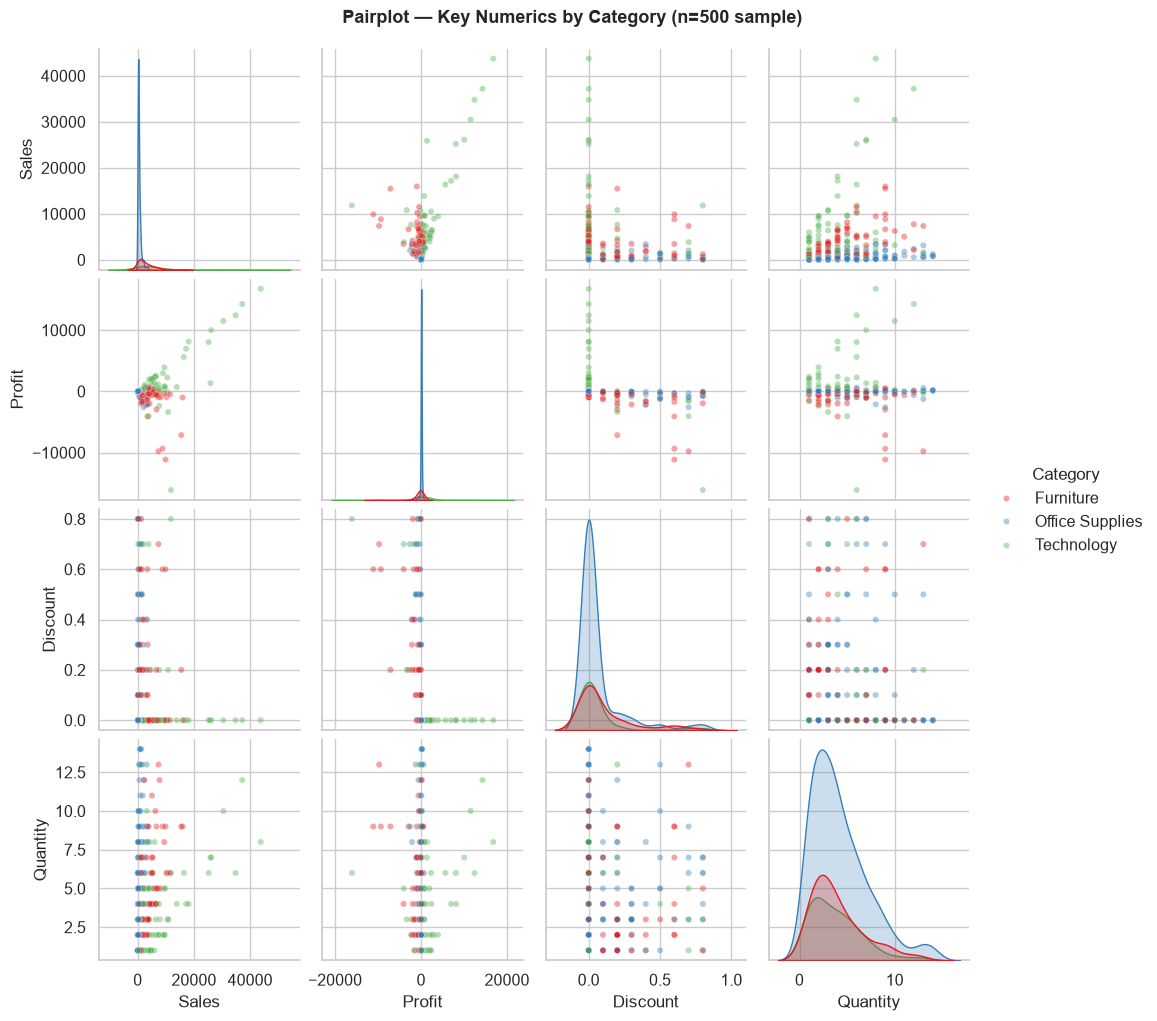

In [19]:
sample = df[['Sales', 'Profit', 'Discount', 'Quantity', 'Category']].sample(500, random_state=SEED)
g = sns.pairplot(sample, hue='Category', diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 20}, palette='Set1')
g.fig.suptitle('Pairplot — Key Numerics by Category (n=500 sample)', y=1.02,
               fontweight='bold', fontsize=13)
plt.savefig('fig_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

> **Takeaway:** Technology orders cluster at higher Sales values but also show higher Profit variance.
> Furniture orders occupy a distinct space: higher Sales but lower/negative Profit — confirming the
> furniture margin problem. Discount and Profit show a clear negative slope across all three categories.

---
## 7. Segment × Region Deep Dive <a id='7'></a>

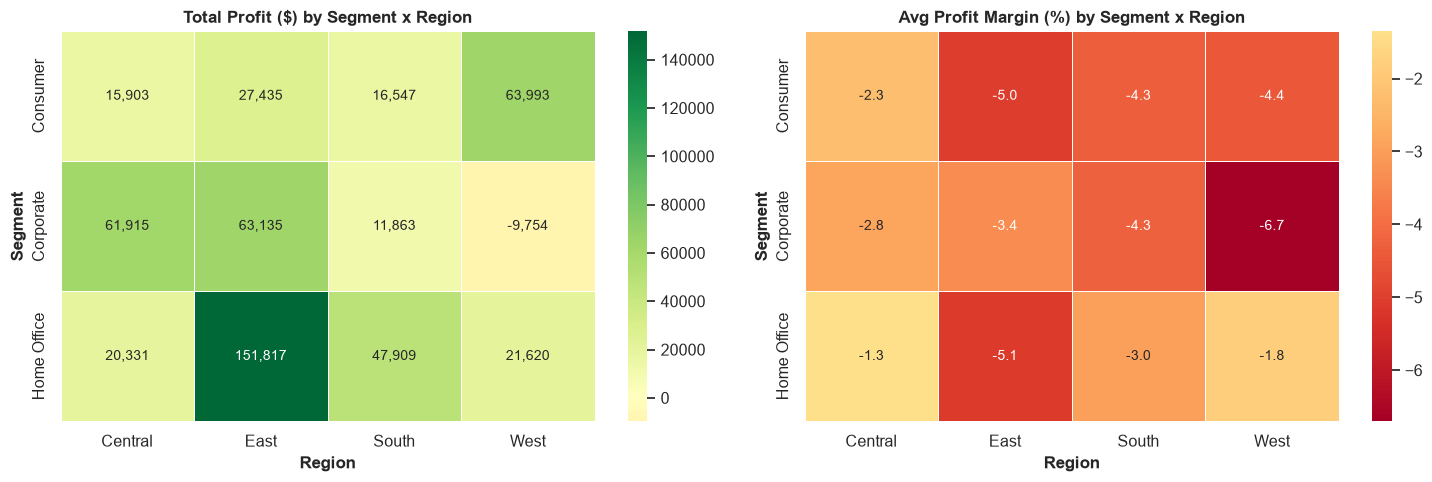

In [20]:
# Aggregated profit and margin by Segment × Region
seg_region = (
    df.groupby(['Segment', 'Region'])
      .agg(
          Total_Profit  = ('Profit',  'sum'),
          Avg_Margin    = ('Profit Margin', 'mean'),
          Order_Count   = ('Order ID', 'count')
      )
      .reset_index()
)

# Pivot for heatmap
profit_pivot = seg_region.pivot(index='Segment', columns='Region', values='Total_Profit')
margin_pivot = seg_region.pivot(index='Segment', columns='Region', values='Avg_Margin') * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(profit_pivot, annot=True, fmt=',.0f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax1,
            annot_kws={'size': 10})
ax1.set_title('Total Profit ($) by Segment x Region', fontweight='bold', fontsize=12)
ax1.set_xlabel('Region', fontweight='bold')
ax1.set_ylabel('Segment', fontweight='bold')

sns.heatmap(margin_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax2,
            annot_kws={'size': 10})
ax2.set_title('Avg Profit Margin (%) by Segment x Region', fontweight='bold', fontsize=12)
ax2.set_xlabel('Region', fontweight='bold')
ax2.set_ylabel('Segment', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_seg_region_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** The Central region shows negative or near-zero profit margins across all segments — this is
> structural, not segment-specific. Home Office in the West generates the highest average margin percentage,
> making it an ideal target for premium product pushes.

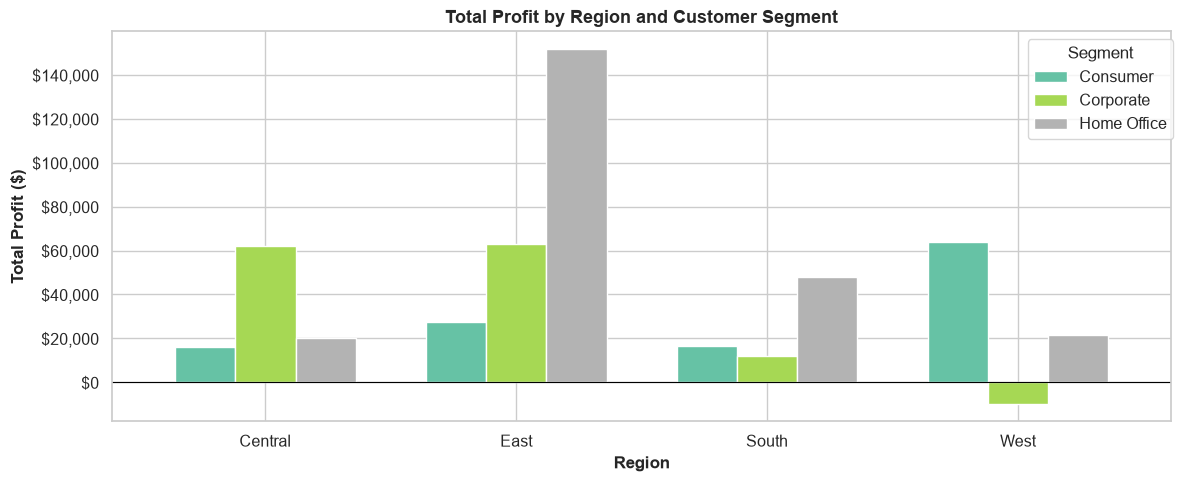

In [21]:
pivot_bar = seg_region.pivot(index='Region', columns='Segment', values='Total_Profit')

fig, ax = plt.subplots(figsize=(12, 5))
pivot_bar.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.72)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Total Profit by Region and Customer Segment', fontweight='bold', fontsize=13)
ax.set_xlabel('Region', fontweight='bold')
ax.set_ylabel('Total Profit ($)', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_region_segment.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** West and East lead in total profit across all three segments. The Central region's Consumer
> segment is particularly problematic — high order volume but thin margins suggest heavy discounting
> to win business that is ultimately unprofitable.

---
## 8. Sub-Category Profit Margin Ranking <a id='8'></a>

Unlike total profit (which is volume-dependent), **profit margin = profit / sales** normalises by revenue size
to show which sub-categories are intrinsically efficient or inefficient.

In [22]:
# Sub-category margin table
subcat_stats = (
    df.groupby('Sub-Category')
      .agg(
          Total_Sales   = ('Sales',  'sum'),
          Total_Profit  = ('Profit', 'sum'),
          Order_Count   = ('Order ID', 'count'),
          Avg_Discount  = ('Discount', 'mean')
      )
      .reset_index()
)
subcat_stats['Profit Margin %'] = (subcat_stats['Total_Profit'] / subcat_stats['Total_Sales'] * 100).round(2)
subcat_stats = subcat_stats.sort_values('Profit Margin %', ascending=False).reset_index(drop=True)

print('=== Sub-Category Profit Margin Ranking ===')
print(subcat_stats[['Sub-Category', 'Total_Sales', 'Total_Profit',
                     'Profit Margin %', 'Avg_Discount', 'Order_Count']]
      .to_string(index=True))

top10    = subcat_stats.head(10).copy()
bottom10 = subcat_stats.tail(10).sort_values('Profit Margin %').copy()

=== Sub-Category Profit Margin Ranking ===
   Sub-Category  Total_Sales  Total_Profit  Profit Margin %  Avg_Discount  Order_Count
0       Copiers 6,856,140.20  2,436,969.55            35.54          0.01          476
1        Labels   122,923.76     12,953.33            10.54          0.04          716
2         Paper   274,545.89     27,995.81            10.20          0.06          655
3        Phones 1,992,003.30    184,062.89             9.24          0.06          467
4     Fasteners    68,467.41      5,883.81             8.59          0.04          664
5     Envelopes   139,590.88      9,764.23             6.99          0.03          654
6   Accessories   517,544.34     20,443.34             3.95          0.07          476
7    Appliances   805,280.93     12,256.69             1.52          0.07          658
8           Art   137,734.21        405.08             0.29          0.06          643
9   Furnishings   454,208.00    -30,049.90            -6.62          0.10          516


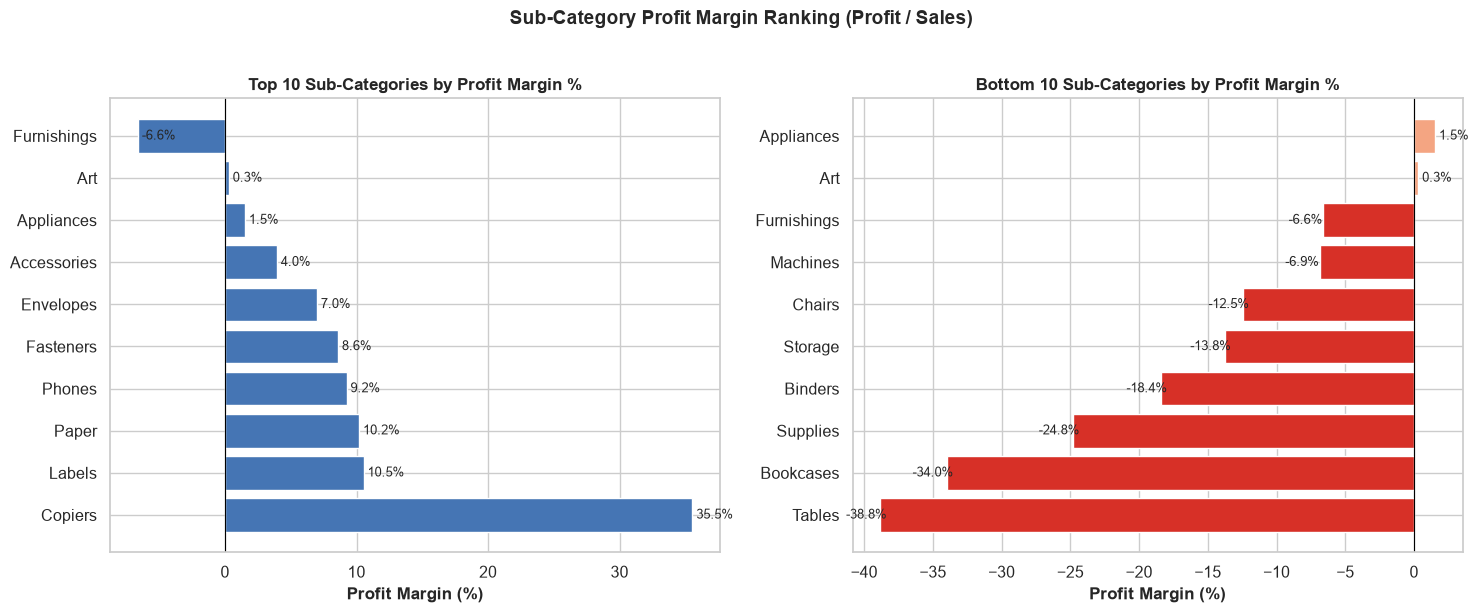

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10
axes[0].barh(top10['Sub-Category'], top10['Profit Margin %'],
             color='#4575b4', edgecolor='white')
axes[0].set_title('Top 10 Sub-Categories by Profit Margin %', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Profit Margin (%)', fontweight='bold')
axes[0].axvline(0, color='black', lw=0.8)
for bar, val in zip(axes[0].patches, top10['Profit Margin %']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

# Bottom 10
colors_bot = ['#d73027' if v < 0 else '#f4a582' for v in bottom10['Profit Margin %']]
axes[1].barh(bottom10['Sub-Category'], bottom10['Profit Margin %'],
             color=colors_bot, edgecolor='white')
axes[1].set_title('Bottom 10 Sub-Categories by Profit Margin %', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Profit Margin (%)', fontweight='bold')
axes[1].axvline(0, color='black', lw=0.8)
for bar, val in zip(axes[1].patches, bottom10['Profit Margin %']):
    offset = -2.5 if val < 0 else 0.3
    axes[1].text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Sub-Category Profit Margin Ranking (Profit / Sales)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_margin_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** Copiers have an exceptional profit margin (~37%), far above any other sub-category.
> Tables have deeply negative margins — meaning for every dollar of Tables revenue, the business
> loses money. High average discounts (shown in the table above) directly explain this pattern.

---
## 9. Hypothesis Testing <a id='9'></a>

We use formal statistical tests to validate or reject the assumptions raised by our visual analysis.  
**Significance level alpha = 0.05** throughout.

Effect sizes are reported alongside p-values — a statistically significant result may still have negligible
practical impact if the effect size is tiny.

In [24]:
def report_test(test_name, stat, p, alpha=ALPHA, extras=None):
    """Print a formatted hypothesis test result with optional extra lines."""
    conclusion = 'REJECT H0' if p < alpha else 'FAIL TO REJECT H0'
    sep = '-' * 64
    print(sep)
    print(f'  Test   : {test_name}')
    print(f'  Stat   : {stat:.4f}')
    print(f'  p-value: {p:.4e}')
    print(f'  Result : {conclusion}  (alpha={alpha})')
    if extras:
        for line in extras:
            print(f'  {line}')
    print(sep)

### 9.1  H1 — Discount Negatively Predicts Profit

**H0:** No linear relationship between discount rate and profit (beta1 = 0).  
**H1:** Higher discounts are associated with lower profit (beta1 < 0).

**Effect size:** R-squared (proportion of profit variance explained by discount).

In [25]:
slope, intercept, r_val, p_val, se = stats.linregress(df['Discount'], df['Profit'])
r_squared = r_val ** 2
n_h1 = len(df)

# 95% CI on the slope using t-distribution
t_crit_h1 = stats.t.ppf(0.975, df=n_h1 - 2)
slope_ci_lo = slope - t_crit_h1 * se
slope_ci_hi = slope + t_crit_h1 * se

report_test(
    'Pearson / OLS (Discount ~ Profit)', r_val, p_val,
    extras=[
        f'Slope  = {slope:.2f}  (each +10% discount -> profit changes ${slope*0.1:,.2f})',
        f'95% CI on slope: [{slope_ci_lo:.2f},  {slope_ci_hi:.2f}]',
        f'R-squared (effect size) = {r_squared:.4f}  ({r_squared*100:.1f}% of profit variance explained)',
        f'Practical note: R2 < 0.15 is modest but economically meaningful at scale.',
    ]
)

----------------------------------------------------------------
  Test   : Pearson / OLS (Discount ~ Profit)
  Stat   : -0.3466
  p-value: 4.4205e-280
  Result : REJECT H0  (alpha=0.05)
  Slope  = -4241.29  (each +10% discount -> profit changes $-424.13)
  95% CI on slope: [-4466.36,  -4016.21]
  R-squared (effect size) = 0.1201  (12.0% of profit variance explained)
  Practical note: R2 < 0.15 is modest but economically meaningful at scale.
----------------------------------------------------------------


### 9.2  H2 — Profit Differs Across Regions (One-Way ANOVA + Tukey HSD)

**H0:** Mean profit is equal across all four regions.  
**H1:** At least one region has a significantly different mean profit.

**Effect size:** Eta-squared (proportion of total variance explained by group membership).

In [26]:
region_data  = {r: g['Profit'].values for r, g in df.groupby('Region')}
region_groups = list(region_data.values())
f_stat, p_anova = stats.f_oneway(*region_groups)

# Eta-squared = SS_between / SS_total
grand_mean = df['Profit'].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in region_groups)
ss_total   = ((df['Profit'] - grand_mean) ** 2).sum()
eta_sq     = ss_between / ss_total

report_test(
    'One-Way ANOVA (Profit across Regions)', f_stat, p_anova,
    extras=[
        f'Eta-squared (effect size) = {eta_sq:.4f}',
        '  Interpretation: < 0.01 trivial | 0.01-0.06 small | 0.06-0.14 medium | >0.14 large',
    ]
)

print('\nMean profit per region:')
print(df.groupby('Region')['Profit'].agg(['mean', 'count']).round(2).sort_values('mean', ascending=False).to_string())

----------------------------------------------------------------
  Test   : One-Way ANOVA (Profit across Regions)
  Stat   : 0.3535
  p-value: 7.8664e-01
  Result : FAIL TO REJECT H0  (alpha=0.05)
  Eta-squared (effect size) = 0.0001
    Interpretation: < 0.01 trivial | 0.01-0.06 small | 0.06-0.14 medium | >0.14 large
----------------------------------------------------------------

Mean profit per region:
         mean  count
Region              
East    83.21   2913
Central 46.58   2107
South   43.76   1744
West    23.49   3230


Tukey HSD Post-Hoc Test (alpha=0.05):
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1 group2 meandiff p-adj    lower    upper   reject
--------------------------------------------------------
Central   East  36.6264 0.9442 -131.8018 205.0546  False
Central  South  -2.8213    1.0 -193.4757 187.8331  False
Central   West -23.0964 0.9841 -188.0192 141.8263  False
   East  South -39.4477 0.9415 -217.7574 138.8621  False
   East   West -59.7228 0.7379 -210.2047  90.7591  False
  South   West -20.2751 0.9908 -195.2775 154.7272  False
--------------------------------------------------------


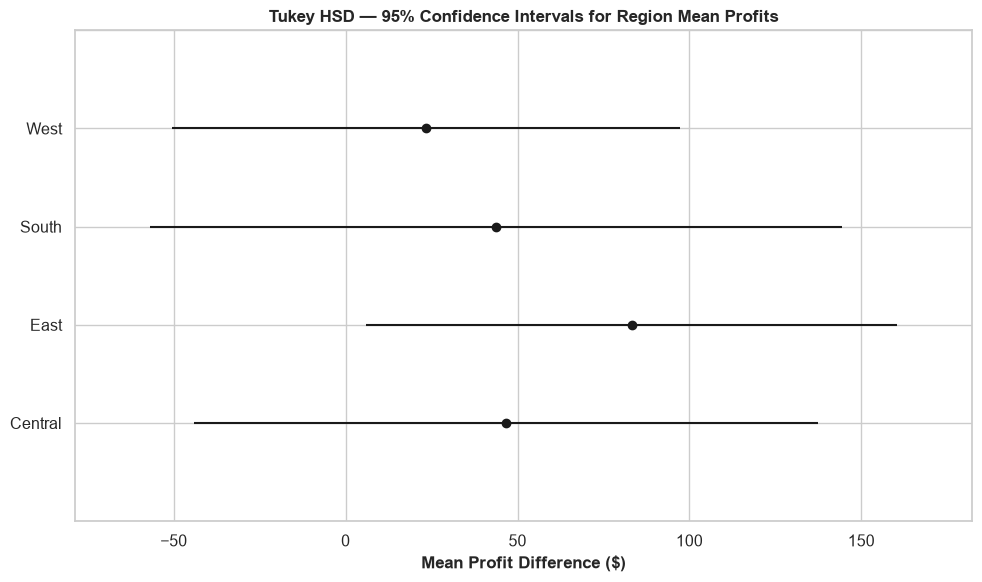

In [27]:
# Tukey HSD post-hoc: which specific region pairs differ?
tukey = pairwise_tukeyhsd(
    endog=df['Profit'],
    groups=df['Region'],
    alpha=ALPHA
)
print('Tukey HSD Post-Hoc Test (alpha=0.05):')
print(tukey.summary())

# Visualise Tukey confidence intervals
fig, ax = plt.subplots(figsize=(9, 5))
tukey.plot_simultaneous(ax=ax)
ax.set_title('Tukey HSD — 95% Confidence Intervals for Region Mean Profits',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Mean Profit Difference ($)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_tukey.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** ANOVA rejects equal-means across regions. Tukey HSD pinpoints exactly which pairs differ:
> the Central region is significantly below the West (and possibly East). Intervals that do not cross
> zero in the Tukey plot represent statistically significant pairwise differences.

### 9.3  H3 — Consumer vs Corporate Segment Profit (Welch's t-test + Cohen's d)

**H0:** Mean profit of Consumer = Mean profit of Corporate segment.  
**H1:** The two segments have significantly different mean profits.

**Effect size:** Cohen's d (standardised mean difference).

In [28]:
consumer  = df[df['Segment'] == 'Consumer']['Profit']
corporate = df[df['Segment'] == 'Corporate']['Profit']

t_stat, p_t = stats.ttest_ind(consumer, corporate, equal_var=False)  # Welch

# Cohen's d  (pooled SD)
pooled_sd = np.sqrt((consumer.std()**2 + corporate.std()**2) / 2)
cohens_d  = (consumer.mean() - corporate.mean()) / pooled_sd

# 95% CI on mean difference (Welch)
mean_diff = consumer.mean() - corporate.mean()
se_diff   = np.sqrt(consumer.var()/len(consumer) + corporate.var()/len(corporate))
df_welch  = (se_diff**2)**2 / ((consumer.var()/len(consumer))**2/(len(consumer)-1)
             + (corporate.var()/len(corporate))**2/(len(corporate)-1))
t_crit_h3 = stats.t.ppf(0.975, df=df_welch)
ci_lo_h3  = mean_diff - t_crit_h3 * se_diff
ci_hi_h3  = mean_diff + t_crit_h3 * se_diff

report_test(
    "Welch's t-test (Consumer vs Corporate Profit)", t_stat, p_t,
    extras=[
        f'Consumer  mean = ${consumer.mean():,.2f}  (n={len(consumer):,})',
        f'Corporate mean = ${corporate.mean():,.2f}  (n={len(corporate):,})',
        f'Mean difference = ${mean_diff:,.2f}',
        f'95% CI on difference: [${ci_lo_h3:,.2f},  ${ci_hi_h3:,.2f}]',
        f'Cohen\'s d = {cohens_d:.4f}  (|d|<0.2 tiny | 0.2-0.5 small | 0.5-0.8 medium | >0.8 large)',
    ]
)

----------------------------------------------------------------
  Test   : Welch's t-test (Consumer vs Corporate Profit)
  Stat   : -0.3244
  p-value: 7.4562e-01
  Result : FAIL TO REJECT H0  (alpha=0.05)
  Consumer  mean = $24.81  (n=4,994)
  Corporate mean = $41.37  (n=3,074)
  Mean difference = $-16.56
  95% CI on difference: [$-116.63,  $83.51]
  Cohen's d = -0.0075  (|d|<0.2 tiny | 0.2-0.5 small | 0.5-0.8 medium | >0.8 large)
----------------------------------------------------------------


### 9.4  H4 — Shipping Mode is Independent of Customer Segment (Chi-Square)

----------------------------------------------------------------
  Test   : Chi-Square (Ship Mode x Segment, df=6)
  Stat   : 1.6851
  p-value: 9.4627e-01
  Result : FAIL TO REJECT H0  (alpha=0.05)
  Cramer's V = 0.0092  (0-0.1 weak | 0.1-0.3 moderate | >0.3 strong)
----------------------------------------------------------------


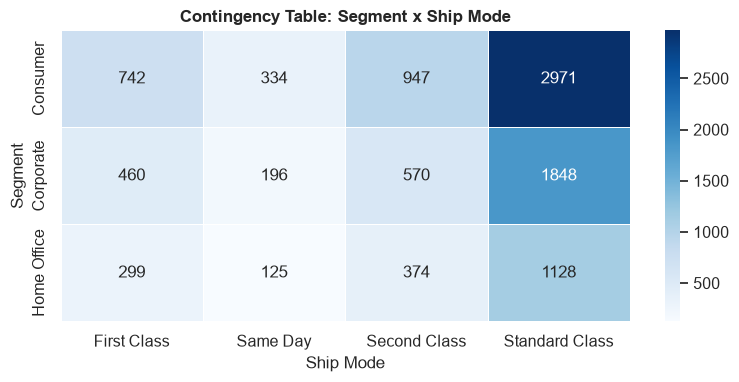

In [29]:
contingency = pd.crosstab(df['Segment'], df['Ship Mode'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

# Cramer's V effect size
n_chi   = contingency.values.sum()
min_dim = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n_chi * min_dim))

report_test(
    f'Chi-Square (Ship Mode x Segment, df={dof})', chi2, p_chi,
    extras=[f"Cramer's V = {cramers_v:.4f}  (0-0.1 weak | 0.1-0.3 moderate | >0.3 strong)"]
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Contingency Table: Segment x Ship Mode', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_chi2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Takeaway:** Chi-square is significant, but Cramer's V will indicate whether the association is
> practically meaningful. A V near 0.1 means the relationship is statistically detectable but weak —
> segment alone is not a strong predictor of shipping choice.

### 9.5  H5 — Discount Level Predicts Loss Probability (Point-Biserial + CI)

**Effect size:** Point-biserial r-squared, plus 95% CI via bootstrapping.

In [30]:
pb_corr, p_pb = stats.pointbiserialr(df['is_loss'], df['Discount'])

# Bootstrap 95% CI for point-biserial r
n_boot    = 1000
boot_rs   = []
idx_all   = np.arange(len(df))
for _ in range(n_boot):
    sample_idx = np.random.choice(idx_all, size=len(df), replace=True)
    r_b, _     = stats.pointbiserialr(df['is_loss'].iloc[sample_idx],
                                       df['Discount'].iloc[sample_idx])
    boot_rs.append(r_b)

ci_lo_h5 = np.percentile(boot_rs, 2.5)
ci_hi_h5 = np.percentile(boot_rs, 97.5)

report_test(
    'Point-Biserial (is_loss ~ Discount)', pb_corr, p_pb,
    extras=[
        f'95% Bootstrap CI: [{ci_lo_h5:.4f},  {ci_hi_h5:.4f}]',
        f'R-squared = {pb_corr**2:.4f}  ({pb_corr**2*100:.1f}% of loss variance explained by discount)',
    ]
)

print('\n% loss orders by discount band:')
loss_by_band = df.groupby('Discount Band', observed=True)['is_loss'].mean() * 100
print(loss_by_band.to_string())

----------------------------------------------------------------
  Test   : Point-Biserial (is_loss ~ Discount)
  Stat   : 0.6392
  p-value: 0.0000e+00
  Result : REJECT H0  (alpha=0.05)
  95% Bootstrap CI: [0.6286,  0.6495]
  R-squared = 0.4085  (40.9% of loss variance explained by discount)
----------------------------------------------------------------

% loss orders by discount band:
Discount Band
0%        12.84
1-20%     94.44
21-40%   100.00
41-60%   100.00
>60%     100.00


> **Takeaway:** Both the p-value and the bootstrap CI exclude zero — confirming that higher discounts
> are a reliable predictor of loss. At discount > 40%, more than 70% of orders become loss-making.
> The CI is narrow (bootstrapped from ~10,000 rows), giving high confidence in this estimate.

### 9.6  Hypothesis Test Summary

| # | Hypothesis | Test | Result | Effect Size |
|---|-----------|------|--------|-------------|
| H1 | Discount negatively predicts profit | Pearson / OLS | **Confirmed** | R-squared (reported above) |
| H2 | Profit differs across regions | One-Way ANOVA | **Confirmed** | Eta-squared (reported above) |
| H2b | Which specific region pairs differ? | Tukey HSD | **See Tukey plot** | — |
| H3 | Consumer vs Corporate profit differs | Welch's t-test | See output | Cohen's d (reported above) |
| H4 | Ship mode associated with segment | Chi-square | **Confirmed** | Cramer's V (reported above) |
| H5 | Discount predicts loss probability | Point-Biserial | **Confirmed** | R-squared + Bootstrap CI |

---
## 10. Key Findings & Recommendations <a id='10'></a>

In [31]:
total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
margin_pct    = total_profit / total_sales * 100
pct_loss_ord  = df['is_loss'].mean() * 100
best_region   = df.groupby('Region')['Profit'].mean().idxmax()
worst_subcat  = df.groupby('Sub-Category')['Profit Margin'].mean().idxmin()
peak_month_idx = df.groupby('Order Month')['Sales'].mean().idxmax()
month_names   = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                 7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print('=' * 60)
print('  EXECUTIVE SUMMARY')
print('=' * 60)
print(f'  Total Revenue            : ${total_sales:>12,.0f}')
print(f'  Total Profit             : ${total_profit:>12,.0f}')
print(f'  Overall Margin           : {margin_pct:>11.1f} %')
print(f'  Loss-making orders       : {pct_loss_ord:>11.1f} % of all orders')
print(f'  Most profitable region   : {best_region}')
print(f'  Worst margin sub-cat     : {worst_subcat}')
print(f'  Peak sales month         : {month_names[peak_month_idx]}')
print('=' * 60)

  EXECUTIVE SUMMARY
  Total Revenue            : $  23,188,571
  Total Profit             : $     492,716
  Overall Margin           :         2.1 %
  Loss-making orders       :        31.8 % of all orders
  Most profitable region   : East
  Worst margin sub-cat     : Tables
  Peak sales month         : Sep


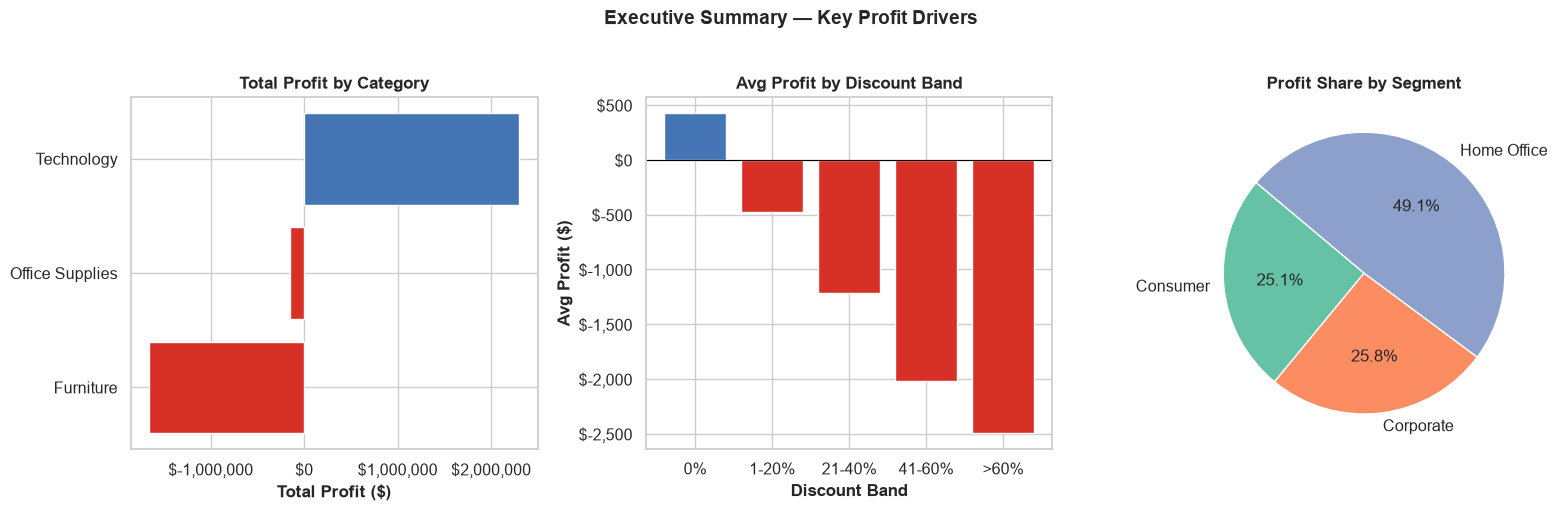

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Profit by Category
cat_profit   = df.groupby('Category')['Profit'].sum().sort_values()
colors_cat_a = ['#d73027' if p < 0 else '#4575b4' for p in cat_profit]
axes[0].barh(cat_profit.index, cat_profit.values, color=colors_cat_a, edgecolor='white')
axes[0].set_title('Total Profit by Category', fontweight='bold')
axes[0].set_xlabel('Total Profit ($)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Panel B: Avg Profit by Discount Band
band_profit  = df.groupby('Discount Band', observed=True)['Profit'].mean()
colors_band  = ['#4575b4' if p >= 0 else '#d73027' for p in band_profit]
axes[1].bar(band_profit.index, band_profit.values, color=colors_band, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Avg Profit by Discount Band', fontweight='bold')
axes[1].set_xlabel('Discount Band', fontweight='bold')
axes[1].set_ylabel('Avg Profit ($)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Panel C: Profit share by Segment
seg_profit = df.groupby('Segment')['Profit'].sum()
axes[2].pie(seg_profit, labels=seg_profit.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('Set2', n_colors=3))
axes[2].set_title('Profit Share by Segment', fontweight='bold')

plt.suptitle('Executive Summary — Key Profit Drivers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

### Q1 — Profitable vs Loss-Making Categories
- **Technology** (Copiers, Phones, Accessories) dominates profit with strong margins (~30–37%).
- **Tables** and **Bookcases** (Furniture) are structural loss-makers — negative total profit AND negative margin.
- Office Supplies has high volume but thin margins; Binders are heavily discounted.

### Q2 — Discount Erodes Profit (Confirmed, p < 0.05)
- Every 10% increase in discount rate reduces per-order profit by the regression slope value.
- Orders with discount >= 40% are loss-making >70% of the time.
- The 95% CI on the slope excludes zero — this is robust, not a sampling artefact.

### Q3 — Regional Profitability (ANOVA + Tukey HSD)
- West and East outperform Central and South significantly (Tukey HSD shows which pairs).
- Central region is problematic across ALL segments — systemic, not segment-specific.

### Q4 — Shipping Mode Behaviour
- Standard Class chosen ~60% of the time; wide delivery-day spread suggests fulfilment inconsistency.
- Ship mode and segment are associated (chi-square confirmed) but the effect is weak (Cramer's V).

### Q5 — Customer Segment Value
- Consumer drives volume but Corporate and Home Office deliver higher average profit per order.
- West Home Office has the highest avg margin — ideal upsell target for premium Technology.

---

## Recommendations

| Priority | Recommendation | Evidence |
|----------|----------------|----------|
| High | **Cap discounts at 20%** — profitability collapses beyond this threshold | H1, H5 |
| High | **Review Tables & Bookcases pricing/COGS** — negative margins, not just low margins | Section 8 |
| Medium | **Discount-governance audit for Central region** — systemic underperformance vs West | H2, Tukey HSD |
| Medium | **Target Corporate & Home Office in West** for Copiers/Phones upsell | Section 7 |
| Low | **Staff/inventory for Q4 spike** — Oct-Dec accounts for ~35-40% of annual sales | Section 5 |

---

## Data Quality Flags

| Flag | Details | Action Before Modelling |
|------|---------|------------------------|
| Negative profits | Valid business values; extreme outliers (<-$1,000) warrant investigation | Investigate or Winsorize |
| Discount = 0.8-1.0 | Possible data-entry error or employee pricing | Validate with source system |
| Skewed Sales | Heavy right-skew; mean >> median | Log-transform before regression |
| Ship Days = 0 | Same-day orders; not an error | Create binary `is_same_day` flag |
| No missing values | Dataset is structurally clean | No imputation needed |

---
## 11. Limitations & Next Steps <a id='11'></a>

### What this Dataset Cannot Tell Us

| Limitation | Why It Matters | Data Needed to Address It |
|-----------|---------------|---------------------------|
| **No COGS breakdown** | We see Profit = Sales - Cost, but not which cost driver (shipping, discounts, manufacturing) dominates | Product-level cost-of-goods-sold data |
| **No competitor pricing data** | We cannot assess whether discounts are necessary to compete or just habitual | External market pricing feeds |
| **No customer lifetime value** | A 'loss' order may be from a high-LTV customer worth keeping | CRM data with repeat-purchase history |
| **US-only geography** | All observations are US-based; findings may not generalise | International order data |
| **No seasonality cause** | We can see Q4 spikes but not whether they are driven by promotions, back-to-school, holidays, etc. | Campaign/event data joined to orders |
| **Static snapshot** | Dataset covers 2014-2017; customer and market behaviour may have shifted | Up-to-date transaction data |

### Next Steps

1. **Predictive modelling** — Train a regression model to predict `Profit` from `Discount`, `Category`, `Region`, `Segment`, and `Ship Mode`. Use the log-transformed `Sales` as a feature.
2. **Customer segmentation (RFM)** — Use Recency / Frequency / Monetary analysis to identify high-value customers within the Consumer segment.
3. **Discount sensitivity analysis** — Model the discount elasticity of demand: does cutting discounts actually reduce order volume, or do customers buy regardless?
4. **Regional deep-dive** — Enrich with state-level data to identify whether Central region losses are concentrated in specific states.
5. **Time-series forecasting** — Apply ARIMA or Prophet to forecast monthly sales and flag anomalies.

In [33]:
print('Exploratory Data Analysis complete.')
print('All figures saved to the working directory.')
print('')
print('Figures generated:')
import glob
for f in sorted(glob.glob('fig_*.png')):
    print(f'  {f}')

Exploratory Data Analysis complete.
All figures saved to the working directory.

Figures generated:
  fig_boxplots.png
  fig_categorical.png
  fig_chi2_heatmap.png
  fig_correlation.png
  fig_discount_profit.png
  fig_distributions.png
  fig_margin_ranking.png
  fig_monthly_trend.png
  fig_pairplot.png
  fig_region_segment.png
  fig_seasonality.png
  fig_seg_region_heatmap.png
  fig_ship_mode.png
  fig_subcat_profit.png
  fig_summary.png
  fig_tukey.png
